In [1]:

from datetime import datetime, timedelta

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Segmentación de Clientes y Generación de Recomendaciones Basadas en Clustering


## Objetivo General

 Segmentar a los clientes en distintos grupos basados en sus patrones de compra y, posteriormente, generar recomendaciones de productos personalizadas para cada segmento. El análisis se enfoca en identificar clientes con comportamientos de compra regulares y predecibles para ofrecerles listas de productos relevantes.

## Pasos del Análisis y Resultados

### 1. Carga y Preprocesamiento Inicial de Datos

* **Paso:** Se importan las librerías necesarias para el análisis de datos, manipulación, modelado y visualización (pandas, numpy, sklearn, matplotlib, seaborn, datetime, etc.).
* **Resultado:** Entorno de Python preparado con todas las herramientas requeridas.

* **Paso:** Carga de los datasets de ventas (`ventas_completo.csv`) y productos (`productos.csv`).
    * Se realiza una limpieza inicial de los datos de ventas (`df_procesar`):
        * La columna `identification_doct` se convierte en `id_client`, se limpia (solo dígitos, sin ceros iniciales).
        * La columna `product` se convierte a string y se limpian espacios.
        * `date_sale` se convierte a formato datetime, se normaliza a fecha (sin hora) y se eliminan filas con fechas inválidas.
        * `domicilio_status` se limpia y convierte a tipo booleano.
    * Se realiza una limpieza de los datos de productos (`productos`):
        * Se renombra `codigo_unico` a `product`.
        * Se seleccionan las columnas `product`, `description`, `brand`, `category`.
        * Se eliminan duplicados por `product` y se limpian espacios en la columna `product`.
* **Resultado:**
    * `df_procesar` (ventas): Después del filtrado inicial de `id_client`, el DataFrame contiene 18,428,064 filas.
    * `productos` (catálogo): DataFrame listo para ser unido con los datos de ventas.
    * Se muestra una vista previa de `df_procesar` (primeras 5 filas, 23 columnas).

### 2. Definición de Parámetros de Filtrado y Segmentación

* **Paso:** Se definen variables para controlar el filtrado de clientes y la identificación de patrones de compra:
    * `last_month = 1`: Para filtrar clientes con actividad en el último mes.
    * `min_purchase_count = 10`: Mínimo de días de compra distintos para considerar un cliente con patrón.
    * `max_median_days = 35`: Mediana máxima de días entre compras.
    * `max_std_days = 3`: Desviación estándar máxima de días entre compras (indicador de regularidad).
* **Resultado:** Parámetros establecidos para los siguientes pasos de filtrado.

### 3. Filtrado de Clientes por Actividad Reciente

* **Paso:** Se filtra `df_procesar` para obtener un subconjunto de clientes (`df_recent`) que hayan realizado compras en el último mes (definido por `last_month`).
* **Resultado:**
    * Se identifican 105,516 clientes únicos con compras en el último mes.
    * El DataFrame `df_recent` contiene 14,132,757 filas correspondientes a estos clientes.
    * Se muestra una vista previa de `df_recent`.

### 4. Cálculo de Patrones de Compra y Filtrado Avanzado

* **Paso:**
    * Se define una función auxiliar `get_first_mode` para calcular la moda en las agregaciones.
    * Se calculan diversas métricas de comportamiento de compra para cada cliente en `df_recent` (agrupando por `id_client`):
        * Fechas de primera y última compra.
        * Número de días distintos con compras (`purchase_days_count`).
        * Promedio, mediana y desviación estándar de días entre compras.
        * Número de productos únicos comprados (`count_products`).
        * Monto promedio de compra (`pay_amount_mean`).
        * Punto de venta más frecuente y estado de domicilio más frecuente.
    * Este DataFrame de patrones (`patterns`) se filtra para obtener `patterns_filtered` basado en los parámetros definidos en el paso 2 (`min_purchase_days`, `max_median_days_between_purchases`, `max_std_days_between_purchases`).
    * Finalmente, se crea `df_filtered_pattern` al filtrar las ventas de `df_recent` para incluir solo a los clientes presentes en `patterns_filtered`.
* **Resultado:**
    * Inicialmente, 43,740 clientes tenían >= 10 días de compra.
    * Todos estos 43,740 clientes también cumplían con la mediana <= 35 días.
    * Después de aplicar el filtro de desviación estándar (std <= 3 días), `patterns_filtered` contiene 4,862 clientes.
    * `df_filtered_pattern` (ventas de estos 4,862 clientes) contiene 2,363,725 filas y 6 columnas seleccionadas.
    * Se muestran vistas previas de `df_filtered_pattern` y `patterns_filtered`.

### 5. Preparación para Clustering y Selección de K

* **Paso:**
    * Se seleccionan las características de `patterns_filtered` para el clustering: `median_days_between`, `std_days_between`, `pay_amount_mean`, `count_products`.
    * Se verifica que no haya valores nulos en estas características (y se rellenarían con la media si los hubiera, aunque no fue el caso).
    * Las características seleccionadas (`X_clustering`) se escalan usando `StandardScaler` (`X_scaled`).
    * Se aplica el **Método del Codo** (calculando la inercia para K de 1 a 10) para ayudar a determinar un número óptimo de clústeres.
    * Se aplica el **Coeficiente de Silueta** (para K de 2 a 10) como otra métrica para seleccionar K.
* **Resultado:**
    * `X_clustering` no presenta valores nulos.
    * Se genera un gráfico del Método del Codo.
    * Se genera un gráfico del Coeficiente de Silueta. El análisis del coeficiente de silueta sugiere que **K=3** es el mejor número de clústeres.

### 6. Aplicación de K-Means y Análisis de Clústeres

* **Paso:**
    * Se aplica el algoritmo K-Means a los datos escalados (`X_scaled`) con `chosen_k = 3`.
    * Se asigna la etiqueta del clúster resultante a cada cliente en `patterns_filtered` (nueva columna `purchase_pattern_cluster`).
    * Se realiza un análisis descriptivo de los clústeres, agrupando por `purchase_pattern_cluster` y calculando métricas promedio para cada uno.
    * Se visualizan los clústeres usando gráficos de dispersión:
        * `median_days_between` vs `count_products`.
        * `median_days_between` vs `pay_amount_mean`.
* **Resultado:**
    * Los 4,862 clientes filtrados son asignados a uno de los 3 clústeres.
    * **Resumen de Características de los Clústeres (`cluster_summary`):**

        * **Clúster 0:** 1,537 clientes. Caracterizados por una frecuencia de compra muy alta (mediana de días entre compras 1.44) y una regularidad también alta (std. días 1.38). Compran una cantidad considerable de productos diferentes (promedio 49) con un ticket promedio más bajo (39,768).

        * **Clúster 1:** 2,726 clientes (el más grande). Frecuencia de compra alta (mediana de días 2.88) y buena regularidad (std. días 2.44). Compran menos variedad de productos que el clúster 0 (promedio 30) pero con un ticket promedio mayor (77,454).

        * **Clúster 2:** 599 clientes. Frecuencia de compra menor comparada con los otros dos (mediana de días 6.51) pero aún con buena regularidad (std. días 2.44). Compran la menor variedad de productos (promedio 16) pero tienen el ticket promedio más alto por visita (262,672).



### 7. Generación de Recomendaciones por Clúster

* **Paso:**
    * Se unen los datos de ventas de los clientes segmentados (`df_filtered_pattern`) con sus asignaciones de clúster (`patterns_filtered`) y las descripciones de los productos (`productos`).
    * Se excluyen ciertos productos de las recomendaciones (ej. 'BOLSA PLASTICA').
    * Para cada clúster:
        * Se determina el número `top_n` de productos a recomendar, basándose en el promedio de `count_products` para ese clúster (obtenido de `cluster_summary`).
        * Se identifican los `top_n` productos (descripciones) más frecuentemente comprados por los clientes pertenecientes a ese clúster.
        * Estas listas de productos se almacenan en un diccionario `recommendations`.
    * Se crea un DataFrame final `df_client_recommendations` que mapea cada `id_client` a su clúster y a la lista de productos recomendados para dicho clúster.
* **Resultado:**
    * `df_sales_with_clusters` es creado para facilitar la búsqueda de los productos más populares por clúster.
    * Se genera un diccionario `recommendations` donde cada llave es un ID de clúster y el valor es una lista de descripciones de productos recomendados.
        * Clúster 0: Se recomiendan 49 productos (ej. TOMATE CHONTO, PLATANO, BANANO CRIOLLO...).
        * Clúster 1: Se recomiendan 30 productos (ej. TOMATE CHONTO, PLATANO, BANANO CRIOLLO...).
        * Clúster 2: Se recomiendan 16 productos (ej. TOMATE CHONTO, PLATANO, ZANAHORIA...).
    * Se crea `df_client_recommendations` con las columnas `id_client`, `purchase_pattern_cluster`, y `recommended_products`. Se muestra una vista previa.
    * Se muestran ejemplos de recomendaciones para clientes específicos de cada clúster, ilustrando las listas de productos generadas.
    * Se realizan comparaciones entre las listas de recomendaciones de los diferentes clústeres, mostrando productos únicos o compartidos. Por ejemplo, se observa que las recomendaciones del clúster 1 y 2 son subconjuntos de las recomendaciones más amplias del clúster 0, lo cual tiene sentido dado que los clústeres 1 y 2 compran menos variedad de productos en promedio.


In [2]:


df_procesar = pd.read_parquet("../data/processed/initial_sales_clean.parquet")

# Limpiar fechas, productos domicilio
df_procesar['product'] = df_procesar['product'].astype(str).str.strip()
df_procesar['date_sale'] = pd.to_datetime(df_procesar['date_sale'])
df_procesar = df_procesar.dropna(subset=['date_sale'])
df_procesar['date_sale'] = df_procesar['date_sale'].dt.normalize()

productos = pd.read_csv(
    f"../data/processed/productos.csv",
    dtype={"codigo_unico": str}
).rename(columns={"codigo_unico": "product"})
productos = productos.loc[:, ["product", "description", "brand", "category"]]
productos = productos.drop_duplicates("product")
productos['product'] = productos['product'].str.strip()
print(f"Datos cargados Filas: {len(df_procesar)}")

Datos cargados Filas: 18345683


In [3]:
df_procesar.head()

,date_sale,id_client,product,invoice_value_with_discount_and_without_iva,amount
0,2024-11-18,900137588,81314,17721.0,0.360
1,2024-11-18,900137588,81601,17721.0,1.330
2,2024-11-18,900137588,81286,17721.0,0.110
3,2024-11-18,900137588,81541,17721.0,0.385
4,2024-11-18,900137588,249067,17721.0,1.000


In [4]:
last_month = 1
min_purchase_count = 10
max_median_days = 35
max_std_days = 3

In [5]:
print(f"Filtrando clientes con compras en los últimos {last_month} meses...")
three_months_ago = datetime.now().date() - timedelta(days=last_month*30)
recent_purchases = df_procesar[df_procesar["date_sale"].dt.date >= three_months_ago]["id_client"].unique()
print(f"Clientes únicos con compras en los últimos {last_month} meses: {len(recent_purchases)}")
df_recent = df_procesar[df_procesar["id_client"].isin(recent_purchases)].copy()
print(f"Filas tras filtrar por actividad reciente: {len(df_recent)}")


Filtrando clientes con compras en los últimos 1 meses...
Clientes únicos con compras en los últimos 1 meses: 114031
Filas tras filtrar por actividad reciente: 14575524


In [6]:
df_recent.head()

,date_sale,id_client,product,invoice_value_with_discount_and_without_iva,amount
0,2024-11-18,900137588,81314,17721.0,0.360
1,2024-11-18,900137588,81601,17721.0,1.330
2,2024-11-18,900137588,81286,17721.0,0.110
3,2024-11-18,900137588,81541,17721.0,0.385
4,2024-11-18,900137588,249067,17721.0,1.000


In [7]:
def get_first_mode(series):
    mode_series = series.mode()
    if not mode_series.empty:
        return mode_series.iloc[0]
    return np.nan # O None, o un string como "DESCONOCIDO"

In [10]:
print("Calculando y filtrando por patrones de compra...")
cols = [
'id_client',
'date_sale', 

'invoice_value_with_discount_and_without_iva',

'product'
    
]
daily_purchases = df_recent.drop_duplicates(subset=['id_client', 'date_sale'])[cols]
daily_purchases = daily_purchases.sort_values(['id_client', 'date_sale'])
daily_purchases['days_between_purchases'] = daily_purchases.groupby('id_client')['date_sale'].diff().dt.days
patterns = daily_purchases.groupby('id_client').agg(
    last_purchase_date=('date_sale', 'max'),
    first_purchase_date=('date_sale', 'min'),
    purchase_days_count=('date_sale', 'nunique'),
    avg_days_between=('days_between_purchases', 'mean'),
    count_products=('product', 'nunique'),
    median_days_between=('days_between_purchases', 'median'),
    std_days_between=('days_between_purchases', 'std'),
    pay_amount_mean=("invoice_value_with_discount_and_without_iva", "mean"),

).reset_index()



patterns_filtered = patterns[patterns['purchase_days_count'] >= min_purchase_count].copy()
print(f"Clientes con >= {min_purchase_count} días de compra: {len(patterns_filtered)}")
patterns_filtered = patterns_filtered[patterns_filtered["median_days_between"] < max_median_days]
print(f"Clientes con mediana <= {max_median_days} días entre compras: {len(patterns_filtered)}")
patterns_filtered = patterns_filtered[patterns_filtered["std_days_between"] <= max_std_days]
print(f"Clientes con std <= {max_std_days} días entre compras: {len(patterns_filtered)}")

df_filtered_pattern = df_recent[df_recent["id_client"].isin(patterns_filtered["id_client"])]

df_filtered_pattern = df_filtered_pattern[cols]
print(f"Filas tras filtrar por patrones en clientes recientes: {len(df_filtered_pattern)}")

Calculando y filtrando por patrones de compra...
Clientes con >= 10 días de compra: 44956
Clientes con mediana <= 35 días entre compras: 44956
Clientes con std <= 3 días entre compras: 4670
Filas tras filtrar por patrones en clientes recientes: 2259276


In [11]:
df_filtered_pattern.head()

,id_client,date_sale,invoice_value_with_discount_and_without_iva,product
0,900137588,2024-11-18,17721.0,81314
1,900137588,2024-11-18,17721.0,81601
2,900137588,2024-11-18,17721.0,81286
3,900137588,2024-11-18,17721.0,81541
4,900137588,2024-11-18,17721.0,249067


In [12]:
# Asegurémonos de que patterns_filtered y df_filtered_pattern existan y no estén vacíos
if patterns_filtered.empty:
    print("El DataFrame 'patterns_filtered' está vacío. No se puede proceder con el clustering.")
else:
    print(f"\n--- Iniciando Clustering de Clientes por Patrón de Compra ---")
    print(f"Clientes a clusterizar: {len(patterns_filtered)}")
    print(f"Productos Unicos: {df_filtered_pattern['product'].nunique()}")


--- Iniciando Clustering de Clientes por Patrón de Compra ---
Clientes a clusterizar: 4670
Productos Unicos: 15865


In [13]:
patterns_filtered

,id_client,last_purchase_date,first_purchase_date,purchase_days_count,avg_days_between,count_products,median_days_between,std_days_between,pay_amount_mean
13,1000084295,2025-05-16,2025-03-04,22,3.476190,21,3.0,2.482318,17216.454545
16,1000085833,2025-05-16,2024-11-19,65,2.781250,46,2.0,2.406794,9139.600000
19,1000088250,2025-05-17,2024-12-05,80,2.063291,43,2.0,1.389907,6953.475000
25,1000089824,2025-05-16,2024-11-21,87,2.046512,63,2.0,1.282525,57937.425287
44,1000100335,2025-05-15,2024-11-20,67,2.666667,36,2.0,2.289329,5981.328358
...,...,...,...,...,...,...,...,...,...
113905,98765655,2025-05-15,2024-11-21,45,3.977273,26,3.0,2.367303,220884.488889
113916,98766448,2025-05-17,2024-11-18,57,3.214286,27,2.0,2.612657,188725.105263
114007,9920101,2025-05-17,2024-11-23,44,4.069767,25,4.0,2.814887,46696.818182
114009,9921558,2025-05-14,2024-11-18,53,3.403846,26,3.0,1.870929,89325.830189


In [15]:
# 1. Preparación de Datos para Clustering
    # Seleccionamos las características para el clustering.
    # 'median_days_between' es la principal.
    # 'std_days_between' puede ayudar a diferenciar clientes con la misma mediana pero diferente regularidad.
    # 'pay_amount_mean' intentemos este caso
features_for_clustering = [
    'median_days_between', 
    'std_days_between', 
    'pay_amount_mean',
    'count_products'
    #"most_frequent_point_sale",
                           
                           ]

X_clustering = patterns_filtered[features_for_clustering].copy()




In [16]:
X_clustering.isnull().sum()

median_days_between    0
std_days_between       0
pay_amount_mean        0
count_products         0
dtype: int64

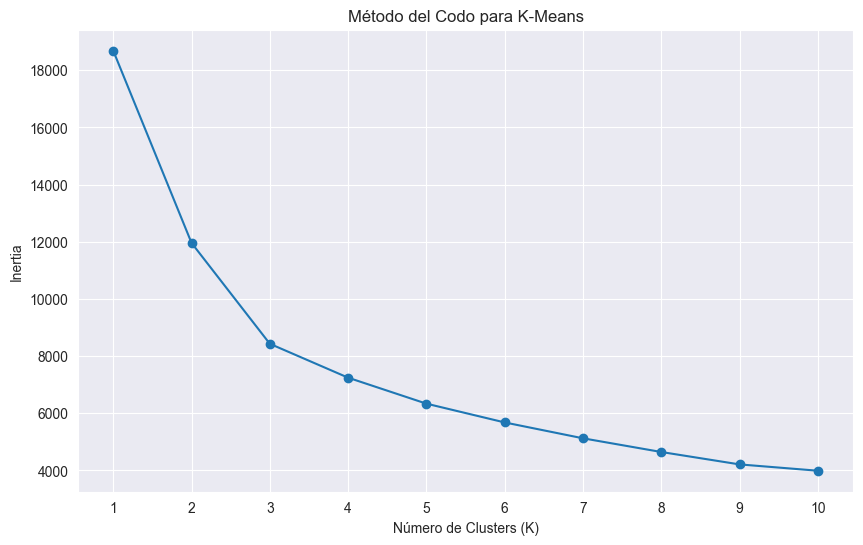

In [17]:
X_clustering.fillna(X_clustering.mean(), inplace=True) # Relleno general por si acaso

if X_clustering.empty or X_clustering.isnull().any().any():
    print("Problemas con los datos para clustering (vacío o NaNs después de rellenar). Revisa los pasos previos.")
else:
    # Escalar las características
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clustering)

    # 2. Elegir Número de Clusters (K) - Método del Codo (Ejemplo)
    inertia = []
    k_range = range(1, 11) # Prueba con K de 1 a 10
    for k in k_range:
        kmeans_model = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans_model.fit(X_scaled)
        inertia.append(kmeans_model.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(k_range, inertia, marker='o')
    plt.title('Método del Codo para K-Means')
    plt.xlabel('Número de Clusters (K)')
    plt.ylabel('Inertia')
    plt.xticks(k_range)
    plt.grid(True)
    plt.show()

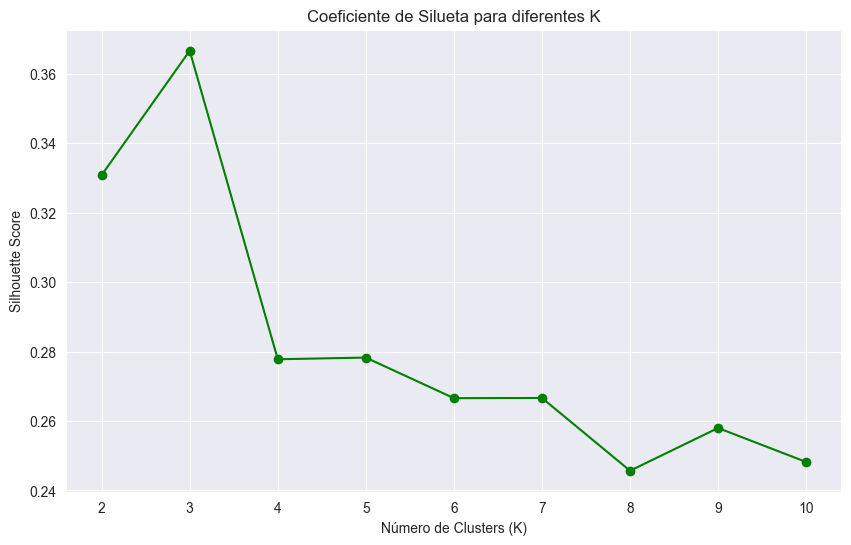

Mejor número de clusters según Silhouette Score: 3


In [18]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans_model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.title('Coeficiente de Silueta para diferentes K')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.xticks(range(2, 11))
plt.show()

# Imprimir el mejor K según la silueta
best_k = range(2, 11)[np.argmax(silhouette_scores)]
print(f"Mejor número de clusters según Silhouette Score: {best_k}")


In [19]:
# Aplicar K-Means con el K elegido
chosen_k = 3
kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init='auto')
patterns_filtered['purchase_pattern_cluster'] = kmeans.fit_predict(X_scaled)

In [20]:
# 3. Interpretar los Clusters
print("\n--- Características de los Clusters ---")
cluster_summary = patterns_filtered.groupby('purchase_pattern_cluster').agg(
    count_clients=('id_client', 'count'),
    avg_median_days=('median_days_between', 'mean'),
    avg_std_days=('std_days_between', 'mean'),
    avg_count_products=('count_products', 'mean'),
    avg_pay_amount_mean=('pay_amount_mean', 'mean'),
    min_median_days=('median_days_between', 'min'),
    max_median_days=('median_days_between', 'max')
).reset_index()
cluster_summary #avg_count_products


--- Características de los Clusters ---


,purchase_pattern_cluster,count_clients,avg_median_days,avg_std_days,avg_count_products,avg_pay_amount_mean,min_median_days,max_median_days
0,0,2649,2.872593,2.445563,29.876557,76557.486554,1.0,7.0
1,1,565,6.501770,2.448230,15.711504,263706.900981,1.0,17.0
2,2,1456,1.405907,1.391289,49.763736,38749.786759,1.0,3.0


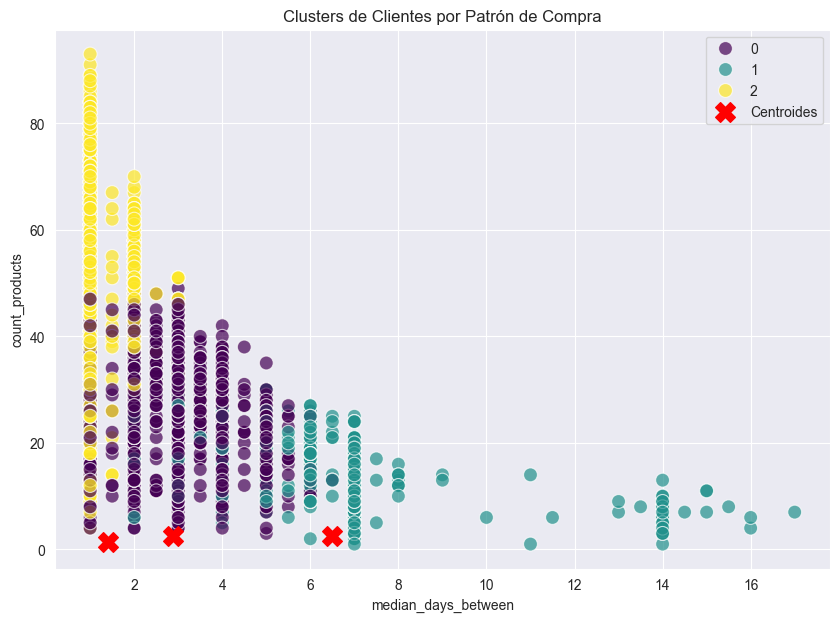

In [21]:
# Visualización de los clusters (opcional, si K es pequeño y usas 2D)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=patterns_filtered, x='median_days_between', y='count_products', hue='purchase_pattern_cluster', palette='viridis', s=100, alpha=0.7)
plt.title('Clusters de Clientes por Patrón de Compra')
#plt.xlabel('Mediana de Días entre Compras')
#plt.ylabel('Desviación Estándar de Días entre Compras')
# Añadir centroides al gráfico
centroids = scaler.inverse_transform(kmeans.cluster_centers_) # Des-escalar centroides
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='red', label='Centroides')
plt.legend()
plt.grid(True)
plt.show()

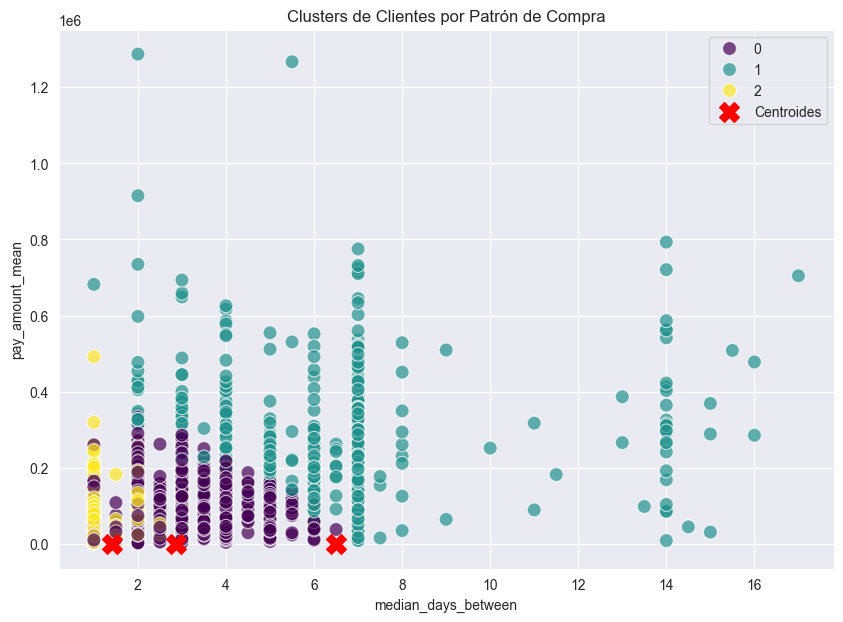

In [22]:
# Visualización de los clusters (opcional, si K es pequeño y usas 2D)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=patterns_filtered, x='median_days_between', y='pay_amount_mean', hue='purchase_pattern_cluster', palette='viridis', s=100, alpha=0.7)
plt.title('Clusters de Clientes por Patrón de Compra')
#plt.xlabel('Mediana de Días entre Compras')
#plt.ylabel('Desviación Estándar de Días entre Compras')
# Añadir centroides al gráfico
centroids = scaler.inverse_transform(kmeans.cluster_centers_) # Des-escalar centroides
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='red', label='Centroides')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# 4. Generar Recomendaciones por Cluster
print("\n--- Generando Recomendaciones (Ejemplo Básico) ---")

df_sales_with_clusters = pd.merge(
    df_filtered_pattern[['id_client', 'product']],
    patterns_filtered[['id_client', 'purchase_pattern_cluster']],
    on='id_client',
    how='left' 
    )
df_sales_with_clusters = pd.merge(
    df_sales_with_clusters,
    productos[["product", "description"]],
    on='product',
    how='left'
)

excluir_prod = ['BOLSA PLASTICA', 'BOLSA RECUPERADA', 'MENU EMPLEADOS EURO']

df_sales_with_clusters = df_sales_with_clusters[~df_sales_with_clusters['description'].isin(excluir_prod)]


--- Generando Recomendaciones (Ejemplo Básico) ---


In [24]:
df_sales_with_clusters["description"].value_counts().head(30)

TOMATE CHONTO                       36775
PLATANO                             30853
BANANO CRIOLLO                      25221
ZANAHORIA                           23994
MANGO TOMY                          21892
LIMON TAHITI                        20913
CEBOLLA BLANCA                      20608
CILANTRO                            18463
AGUACATE LORENA                     17923
AGUACATE HASS                       17636
PAPA CAPIRA KILO                    14581
PAPAYA MARADOL                      13709
MANDARINA ONECA                     13137
CEBOLLA ROJA                        13124
PIMENTON                            12524
PAPA CRIOLLA                        12235
PEPINO COHOMBRO                     11386
PIERNA PULPA.QB                      9946
TOCINO CARNE. QB                     9870
PINA ORO MIEL UNIDAD                 9646
BANANO COMUN                         9168
BROCOLI                              8168
BUNUELO EURO 55 gr                   8137
TABLA QB                          

In [25]:
cluster_summary #avg_count_products

,purchase_pattern_cluster,count_clients,avg_median_days,avg_std_days,avg_count_products,avg_pay_amount_mean,min_median_days,max_median_days
0,0,2649,2.872593,2.445563,29.876557,76557.486554,1.0,7.0
1,1,565,6.501770,2.448230,15.711504,263706.900981,1.0,17.0
2,2,1456,1.405907,1.391289,49.763736,38749.786759,1.0,3.0


In [26]:
# 2. Generar recomendaciones dinámicamente
recommendations = {}

if not patterns_filtered.empty:
    for cluster_id in sorted(patterns_filtered['purchase_pattern_cluster'].unique()):
        # Número de productos a recomendar para este cluster (redondeado)
        top_n = int(round(
            cluster_summary.loc[cluster_summary['purchase_pattern_cluster'] == cluster_id, 'avg_count_products'].values[0]
        ))

        # Clientes en este cluster
        clients_in_cluster = patterns_filtered[
            patterns_filtered['purchase_pattern_cluster'] == cluster_id
        ]['id_client']

        # Ventas de estos clientes
        sales_cluster = df_sales_with_clusters[
            df_sales_with_clusters['id_client'].isin(clients_in_cluster)
        ]

        if not sales_cluster.empty and "description" in sales_cluster.columns:
            top_products = sales_cluster["description"].value_counts().nlargest(top_n).index
            recommendations[cluster_id] = top_products.tolist()
        else:
            recommendations[cluster_id] = []
else:
    print("patterns_filtered está vacío, no se pueden generar recomendaciones.")

# 3. DataFrame de recomendaciones por cliente
print("\n--- Creando DataFrame de Recomendaciones Precalculadas por Cliente ---")

if not patterns_filtered.empty:
    df_client_recommendations = patterns_filtered[['id_client', 'purchase_pattern_cluster']].copy()

    df_client_recommendations['recommended_products'] = df_client_recommendations[
        'purchase_pattern_cluster'
    ].apply(lambda cid: recommendations.get(cid, []))

    print("\nDataFrame de Recomendaciones por Cliente:")
    display(df_client_recommendations.head(10))
else:
    df_client_recommendations = pd.DataFrame()


--- Creando DataFrame de Recomendaciones Precalculadas por Cliente ---

DataFrame de Recomendaciones por Cliente:


,id_client,purchase_pattern_cluster,recommended_products
13,1000084295,0,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
16,1000085833,0,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
19,1000088250,2,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
25,1000089824,2,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
44,1000100335,0,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
58,1000192471,2,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
59,1000192661,2,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
77,1000213471,0,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
85,1000290044,0,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
89,1000291241,2,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."


In [27]:
df_client_recommendations[df_client_recommendations["purchase_pattern_cluster"] ==2]

,id_client,purchase_pattern_cluster,recommended_products
19,1000088250,2,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
25,1000089824,2,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
58,1000192471,2,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
59,1000192661,2,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
89,1000291241,2,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
...,...,...,...
113514,98669562,2,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
113549,98670273,2,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
113552,98670359,2,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."
113706,98700337,2,"[TOMATE CHONTO, PLATANO, BANANO CRIOLLO, ZANAH..."


In [28]:

print("\nEjemplo de recomendación para un cliente:")
sample_client_id = "1000084295"
sample_recommendation = df_client_recommendations[df_client_recommendations['id_client'] == sample_client_id]['recommended_products'].iloc[0]
print(f"Cliente: {sample_client_id}")
print(f"Cluster: {df_client_recommendations[df_client_recommendations['id_client'] == sample_client_id]['purchase_pattern_cluster'].iloc[0]}")
print(f"Productos Recomendados: {sample_recommendation}")

s1 = set(sample_recommendation)




Ejemplo de recomendación para un cliente:
Cliente: 1000084295
Cluster: 0
Productos Recomendados: ['TOMATE CHONTO', 'PLATANO', 'BANANO CRIOLLO', 'ZANAHORIA', 'MANGO TOMY', 'CEBOLLA BLANCA', 'LIMON TAHITI', 'CILANTRO', 'AGUACATE LORENA', 'AGUACATE HASS', 'PAPAYA MARADOL', 'PAPA CAPIRA KILO', 'CEBOLLA ROJA', 'MANDARINA ONECA', 'PIMENTON', 'PAPA CRIOLLA', 'PEPINO COHOMBRO', 'PINA ORO MIEL UNIDAD', 'TOCINO CARNE. QB', 'BANANO COMUN', 'PIERNA PULPA.QB', 'BROCOLI', 'LECHE COLANTA ENTERA 1000ml', 'AGUACATE INJERTO', 'MANZANA VERDE', 'TABLA QB', 'CEBOLLA JUNCA PELADA UND', 'MANZANA ROYAL GALA', 'LECHE COLANTA SEMIDESCREM 1000ml', 'AJO MALLA']


In [29]:

print("\nEjemplo de recomendación para un cliente:")
sample_client_id = "1000089824"
sample_recommendation = df_client_recommendations[df_client_recommendations['id_client'] == sample_client_id]['recommended_products'].iloc[0]
print(f"Cliente: {sample_client_id}")
print(f"Cluster: {df_client_recommendations[df_client_recommendations['id_client'] == sample_client_id]['purchase_pattern_cluster'].iloc[0]}")
print(f"Productos Recomendados: {sample_recommendation}")
s2 = set(sample_recommendation)


Ejemplo de recomendación para un cliente:
Cliente: 1000089824
Cluster: 2
Productos Recomendados: ['TOMATE CHONTO', 'PLATANO', 'BANANO CRIOLLO', 'ZANAHORIA', 'BUNUELO EURO 55 gr', 'LIMON TAHITI', 'AGUACATE HASS', 'MANGO TOMY', 'JUGO NATURAL X 12 OZ MENU', 'CEBOLLA BLANCA', 'CILANTRO', 'AGUACATE LORENA', 'PAPA CAPIRA KILO', 'PIERNA PULPA.QB', 'SOPA DEL DIA X 300GR', 'CEBOLLA ROJA', 'MANDARINA ONECA', 'AGUA POTABLE TRATADA EUROMAX *1000ML', 'PIMENTON', 'PAPA CRIOLLA', 'TOCINO CARNE. QB', 'PAPAYA MARADOL', 'PEPINO COHOMBRO', 'LECHE COLANTA SEMIDESCREM 1000ml', 'LECHE COLANTA ENTERA 1000ml', 'BANANO COMUN', 'TABLA QB', 'PECHUGA BUCANERO CAMPESINA REFRIGERADA', 'LECH PASTEUR DESLACTOSADA COLANTA1000ml', 'PINA ORO MIEL UNIDAD', 'LECHE UHT DESLACTOSADA EUROMAX x 900ML', 'MANZANA VERDE', 'MANZANA ROYAL GALA', 'AGUACATE INJERTO', 'GASEOSA COCACOLA  *1.5L', 'QUESITO MONTEFRIO 380gr', 'CEBOLLA JUNCA PELADA UND', 'BROCOLI', 'GALLETA FESTIVAL CHOCOLATE', 'COCACOLA  x 600ML', 'EMPANADA DE CARNE  x 1

In [30]:

print("\nEjemplo de recomendación para un cliente:")
sample_client_id = "1017202507"
sample_recommendation = df_client_recommendations[df_client_recommendations['id_client'] == sample_client_id]['recommended_products'].iloc[0]
print(f"Cliente: {sample_client_id}")
print(f"Cluster: {df_client_recommendations[df_client_recommendations['id_client'] == sample_client_id]['purchase_pattern_cluster'].iloc[0]}")
print(f"Productos Recomendados: {sample_recommendation}")
s3 = set(sample_recommendation)


Ejemplo de recomendación para un cliente:
Cliente: 1017202507
Cluster: 1
Productos Recomendados: ['TOMATE CHONTO', 'PLATANO', 'ZANAHORIA', 'MANGO TOMY', 'BANANO CRIOLLO', 'CEBOLLA BLANCA', 'AGUACATE LORENA', 'LIMON TAHITI', 'CILANTRO', 'PAPAYA MARADOL', 'MANDARINA ONECA', 'PAPA CAPIRA KILO', 'CEBOLLA ROJA', 'PIMENTON', 'PAPA CRIOLLA', 'AGUACATE HASS']


In [31]:
s1-s2

set()

In [32]:
s2-s1

{'AGUA POTABLE TRATADA EUROMAX *1000ML',
 'BUNUELO EURO 55 gr',
 'CAÑON.QB',
 'COCACOLA  x 600ML',
 'EMPANADA DE CARNE  x 100GR',
 'FILETE  DE PECHUGA CAMPESINA',
 'GALLETA COCOSETTE WAFER *46GR',
 'GALLETA FESTIVAL CHOCOLATE',
 'GASEOSA COCACOLA  *1.5L',
 'JUGO NATURAL X 12 OZ MENU',
 'LECH PASTEUR DESLACTOSADA COLANTA1000ml',
 'LECHE UHT DESLACTOSADA EUROMAX x 900ML',
 'LECHE UHT ENTERA EUROMAX x 900ML',
 'PAPA CAPIRA OFERTA',
 'PECHUGA BUCANERO CAMPESINA REFRIGERADA',
 'PERA VERDE',
 'PONY MALTA MINI PET  x 200ML',
 'QUESITO MONTEFRIO 380gr',
 'SOPA DEL DIA X 300GR',
 'YUCA'}

In [33]:
s1-s3

{'AGUACATE INJERTO',
 'AJO MALLA',
 'BANANO COMUN',
 'BROCOLI',
 'CEBOLLA JUNCA PELADA UND',
 'LECHE COLANTA ENTERA 1000ml',
 'LECHE COLANTA SEMIDESCREM 1000ml',
 'MANZANA ROYAL GALA',
 'MANZANA VERDE',
 'PEPINO COHOMBRO',
 'PIERNA PULPA.QB',
 'PINA ORO MIEL UNIDAD',
 'TABLA QB',
 'TOCINO CARNE. QB'}

In [34]:
s3-s1

set()

In [35]:
s3-s2

set()